# SV 73/2024 - Danilo Torbica
## Numeričke interpolacione metode za obradu slike

**Tema:** bilinearna, bikubna i interpolacija kubnim splajnovima.

**Obuhvata:**
- povećanje rezolucije slike,
- rekonstrukcija nedostajućih piksela,
- testiranje i analiza rezultata na više primera.

## 1) Priprema
Glavna implementacija ostaje u `src/interpolation`, a ovde se prikazuje pokretanje eksperimenata i analiza rezultata.

In [1]:
import os
import sys
import time
import numpy as np
from PIL import Image
from IPython.display import display, Markdown

cwd = os.getcwd()
if os.path.isdir(os.path.join(cwd, "src")):
    project_root = cwd
elif os.path.isdir(os.path.join(cwd, "..", "src")):
    project_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    project_root = cwd

if project_root not in sys.path:
    sys.path.append(project_root)

from src.utils.image_io import load_image, save_image
from src.interpolation.bilinear import bilinear_interpolation
from src.interpolation.bicubic import bicubic_interpolation
from src.interpolation.spline import spline_interpolation

np.random.seed(42)
print("Project root:", project_root)
print("Import uspesan.")

Project root: c:\Users\PC-user\Desktop\Numericki projekat\image-interpolation
Import uspesan.


## 2) Pomoćne funkcije
Koriste se osnovne metrike (`MSE`, `PSNR`), prikaz slike i jednostavna tabela u markdown formatu.

In [2]:
def mse(a, b):
    d = a.astype(np.float32) - b.astype(np.float32)
    return float(np.mean(d * d))

def psnr(a, b, max_val=255.0):
    e = mse(a, b)
    if e == 0.0:
        return float("inf")
    return float(10.0 * np.log10((max_val * max_val) / e))

def show_image(np_img, title):
    print(title, "| shape:", np_img.shape)
    display(Image.fromarray(np.clip(np_img, 0, 255).astype(np.uint8)))

def to_markdown_table(headers, rows):
    head = "| " + " | ".join(headers) + " |"
    sep = "| " + " | ".join(["---"] * len(headers)) + " |"
    body = ["| " + " | ".join(str(x) for x in r) + " |" for r in rows]
    return "\n".join([head, sep] + body)

def plot_bar(labels, values, title, ylabel):
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(7, 3.8))
        plt.bar(labels, values)
        plt.title(title)
        plt.ylabel(ylabel)
        plt.grid(axis="y", linestyle="--", alpha=0.35)
        plt.show()
    except Exception:
        print("Matplotlib nije dostupan, prikaz samo numericki:")
        for lbl, val in zip(labels, values):
            print(f"  {lbl}: {val}")

## 3) Upscaling primer (vizuelni pregled)
Na jednoj slici (`lenna`) upoređuje se izlaz tri metode i vreme izvršavanja.

Ulazna slika (lenna) | shape: (170, 170, 3)


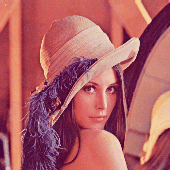

bilinear | vreme: 0.0311s | sacuvano: c:\Users\PC-user\Desktop\Numericki projekat\image-interpolation\user\output\notebook_up_bilinear_lenna.png
bicubic  | vreme: 0.0087s | sacuvano: c:\Users\PC-user\Desktop\Numericki projekat\image-interpolation\user\output\notebook_up_bicubic_lenna.png
spline   | vreme: 0.3768s | sacuvano: c:\Users\PC-user\Desktop\Numericki projekat\image-interpolation\user\output\notebook_up_spline_lenna.png
Upscaled - bilinear | shape: (340, 340, 3)


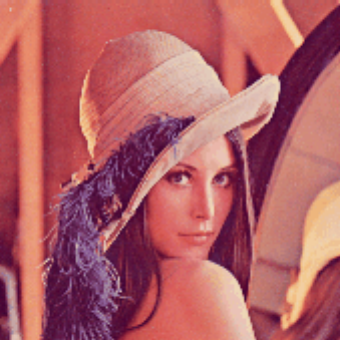

Upscaled - bicubic | shape: (340, 340, 3)


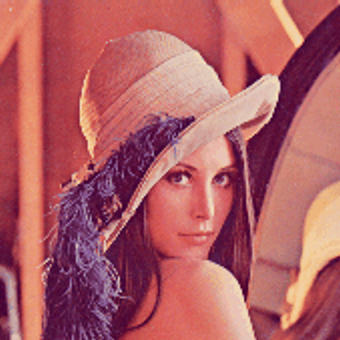

Upscaled - spline | shape: (340, 340, 3)


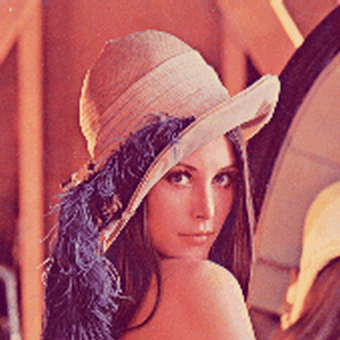

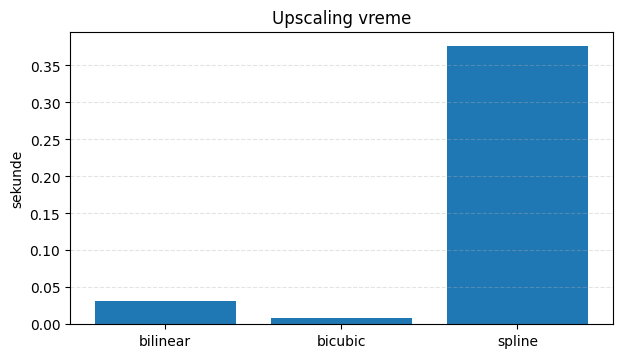

In [3]:
methods = {
    "bilinear": bilinear_interpolation,
    "bicubic": bicubic_interpolation,
    "spline": spline_interpolation,
}

img_name = "lenna"
scale_factor = 2

in_path = os.path.join(project_root, "data", "input", "degraded", f"{img_name}.png")
img = load_image(in_path)
show_image(img, f"Ulazna slika ({img_name})")

up_times = {}
up_outputs = {}

for method_name, fn in methods.items():
    t0 = time.perf_counter()
    out = fn(img, scale_factor=scale_factor)
    dt = time.perf_counter() - t0

    up_times[method_name] = dt
    up_outputs[method_name] = out

    save_path = os.path.join(project_root, "user", "output", f"notebook_up_{method_name}_{img_name}.png")
    save_image(out, save_path)
    print(f"{method_name:8s} | vreme: {dt:.4f}s | sacuvano: {save_path}")

show_image(up_outputs["bilinear"], "Upscaled - bilinear")
show_image(up_outputs["bicubic"], "Upscaled - bicubic")
show_image(up_outputs["spline"], "Upscaled - spline")

plot_bar(list(up_times.keys()), [up_times[k] for k in up_times], "Upscaling vreme", "sekunde")

**Kratak zaključak (upscaling):**
- Sve tri metode rade korektno i daju zadovoljavajuće rezultate.
- Razlika je pre svega u kompromisu kvalitet/detalji, naspram vremena izvršavanja.

## 4) Rekonstrukcija nedostajućih piksela na više slika
Ovde se radi testiranje nad više primera: `lenna`, `barbara`, `foreman`.

Postupak:
1. Učitava se degradirana slika.
2. Nasumično se uklanja 10% piksela.
3. Primenjuje se svaka metoda rekonstrukcije.
4. Izračunavaju se `MSE` i `PSNR` prema odgovarajućoj originalnoj slici.
5. Rezultati se prikazuju tabelarno.

In [ ]:
test_images = ["lenna", "barbara", "foreman"]
missing_ratio = 0.10

rows = []

for image_name in test_images:
    degraded_path = os.path.join(project_root, "data", "input", "degraded", f"{image_name}.png")
    img_degraded = load_image(degraded_path)

    h, w, _ = img_degraded.shape
    local_mask = np.random.rand(h, w) < missing_ratio
    img_missing = img_degraded.copy()
    img_missing[local_mask] = 0

    for method_name, fn in methods.items():
        t0 = time.perf_counter()
        rec = fn(img_missing, missing_mask=local_mask)
        dt = time.perf_counter() - t0

        rec_mse = mse(img_degraded, rec)
        rec_psnr = psnr(img_degraded, rec)

        save_path = os.path.join(project_root, "user", "output_recon", 
                                f"notebook_recon_{method_name}_{image_name}.png")
        save_image(rec, save_path)

        rows.append([
            image_name,
            method_name,
            f"{dt:.4f}",
            f"{rec_mse:.2f}",
            f"{rec_psnr:.2f}",
        ])

headers = ["Slika", "Metoda", "Vreme [s]", "MSE", "PSNR [dB]"]
table_md = to_markdown_table(headers, rows)
display(Markdown(table_md))

ValueError: operands could not be broadcast together with shapes (512,512,3) (170,170,3) 

Nakon tabele se pojedinačno prikazuju i prosečni rezultati po metodi, da poređenje bude jasnije.

In [ ]:
agg = {}
for method_name in methods:
    agg[method_name] = {"time": 0.0, "mse": 0.0, "psnr": 0.0, "n": 0}

for r in rows:
    method_name = r[1]
    agg[method_name]["time"] += float(r[2])
    agg[method_name]["mse"] += float(r[3])
    agg[method_name]["psnr"] += float(r[4])
    agg[method_name]["n"] += 1

avg_rows = []
for method_name in methods:
    n = agg[method_name]["n"]
    avg_t = agg[method_name]["time"] / n
    avg_m = agg[method_name]["mse"] / n
    avg_p = agg[method_name]["psnr"] / n
    avg_rows.append([method_name, f"{avg_t:.4f}", f"{avg_m:.2f}", f"{avg_p:.2f}"])

avg_headers = ["Metoda", "Prosecno vreme [s]", "Prosecni MSE", "Prosecni PSNR [dB]"]
display(Markdown(to_markdown_table(avg_headers, avg_rows)))

labels = [r[0] for r in avg_rows]
avg_time = [float(r[1]) for r in avg_rows]
avg_psnr = [float(r[3]) for r in avg_rows]

plot_bar(labels, avg_time, "Prosecno vreme rekonstrukcije", "sekunde")
plot_bar(labels, avg_psnr, "Prosecni PSNR rekonstrukcije", "dB")

## 5) Finalni zaključak
- Implementirane su tri numeričke metode interpolacije bez uvođenja novih biblioteka.
- Notebook prikazuje i vizuelnu analizu i kvantitativnu analizu (MSE/PSNR + vreme).
- Multi-image test (`lenna`, `barbara`, `foreman`) daje stabilniju procenu ponašanja metoda, od testa na jednoj slici.
- Rezultati su sačuvani u `user/output` i `user/output_recon`.